In [2]:
import os
import qsprpred
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

import torch

from qsprpred.data import QSPRDataset, RandomSplit
from qsprpred.data.descriptors.fingerprints import MorganFP
import pandas as pd
from qsprpred.data.descriptors.sets import RDKitDescs
from MolEval import MolEmb 
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
import numpy as np
import pandas as pd
from sklearn.feature_selection import VarianceThreshold
from qsprpred.data.descriptors.sets import RDKitDescs

/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(
No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'torch_geometric'
Skipped loading modules with pytorch-geometric dependency, missing a depende

In [3]:
X1 = pd.read_csv("CK1/mod_data/X1.1", index_col="QSPRID")
X2 = pd.read_csv("CK1/mod_data/X2.1", index_col="QSPRID")
X3 = pd.read_csv("CK1/mod_data/X3.1", index_col="QSPRID")
y1 = pd.read_csv("CK1/mod_data/y1.1", index_col="QSPRID")
y2 = pd.read_csv("CK1/mod_data/y2.1", index_col="QSPRID")
y3 = pd.read_csv("CK1/mod_data/y3.1", index_col="QSPRID")


In [4]:
X1.columns = X1.columns.astype(str)
X2.columns = X2.columns.astype(str)
X3.columns = X3.columns.astype(str)

imp_mean = SimpleImputer(missing_values=pd.NA, strategy='mean')
X1 = imp_mean.fit_transform(X1)
X2 = imp_mean.transform(X2)
X3 = imp_mean.transform(X3)
scaler = StandardScaler()
scaler.fit(X1)
X1 = scaler.transform(X1)
X2 = scaler.transform(X2)
X3 = scaler.transform(X3)

In [5]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy=0.75, random_state=42)
X1, y1 = smote.fit_resample(X1, y1)
display(pd.DataFrame(X1))

,0,1,2,3,4,5,6,7,8,9,...,2390,2391,2392,2393,2394,2395,2396,2397,2398,2399
0,-0.296463,-1.014346,0.704087,0.197034,-0.199916,0.056990,-1.262282,-0.085669,-1.053805,0.296247,...,-0.290593,-0.165434,-0.601825,-0.120636,-0.322603,-0.237228,-0.160464,-0.331527,-0.101745,0.856668
1,-0.670941,-0.525577,-1.236676,1.502286,0.377970,-0.372174,-0.045401,-0.789457,0.021136,-0.509625,...,-0.290593,-0.165434,-0.601825,-0.120636,-0.322603,-0.237228,-0.160464,-0.331527,-0.101745,-0.299228
2,0.629879,0.514115,-0.293469,1.144865,-1.295461,-1.086432,1.400654,1.220583,1.660234,-0.789349,...,-0.290593,6.044705,1.105679,-0.120636,-0.322603,-0.237228,-0.160464,-0.331527,-0.101745,-0.866536
3,0.373012,-1.030634,0.820882,0.936072,-0.378374,1.713116,1.237002,-0.435967,-0.914606,1.251034,...,-0.290593,-0.165434,1.105679,-0.120636,-0.322603,-0.237228,-0.160464,-0.331527,-0.101745,-0.567226
4,-1.172401,0.684663,-0.397464,-1.756755,1.804830,0.697231,-0.604966,-1.927427,-0.766635,-1.374831,...,-0.290593,-0.165434,-0.601825,-0.120636,-0.322603,-0.237228,-0.160464,-0.331527,-0.101745,1.510832
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
689,-0.423479,-1.437434,-1.799193,-0.455231,0.432731,0.686156,-0.649166,0.463697,0.523452,-0.653612,...,-0.290593,-0.165434,-0.601825,-0.120636,-0.322603,-0.237228,-0.160464,-0.331527,-0.101745,-0.869767
690,1.150509,1.506526,-0.393455,-0.058269,-1.497730,-0.430236,1.281502,0.096219,-0.910398,0.597028,...,-0.290593,-0.165434,0.793435,-0.120636,-0.322603,-0.237228,-0.160464,-0.331527,-0.101745,1.016784
691,0.182195,0.331189,1.590025,-1.375079,-0.489244,-0.632233,0.423024,0.215578,-0.693839,1.184228,...,-0.290593,-0.165434,-0.601825,-0.120636,-0.322603,-0.237228,-0.160464,-0.331527,-0.101745,0.607343
692,-0.541701,-0.848238,-0.325897,-0.011566,-0.542773,-0.197757,0.580143,-0.370656,0.560358,0.915860,...,-0.290593,-0.165434,1.105679,-0.120636,-0.322603,-0.237228,-0.160464,-0.331527,-0.101745,0.537386


In [6]:
from sklearn.decomposition import PCA
pca = PCA(n_components=278)
X1 = pca.fit_transform(X1)
X2 = pca.transform(X2)
X3 = pca.transform(X3)

In [7]:
cum_var = np.cumsum(pca.explained_variance_ratio_)

# Např. najít počet komponent, které vysvětlí 95 % rozptylu
n_components = np.argmax(cum_var >= 0.95) + 1

In [8]:
n_components

1

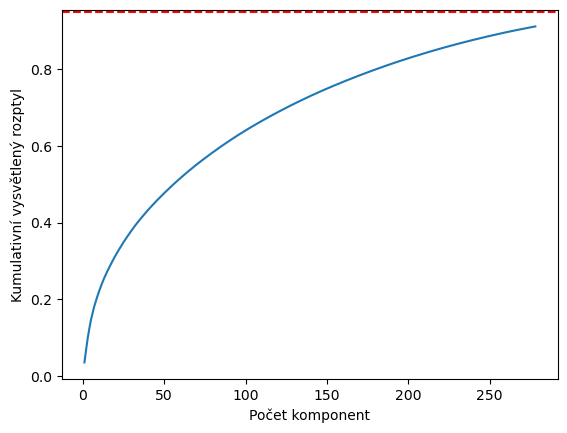

In [9]:
import matplotlib.pyplot as plt

plt.plot(range(1, len(cum_var)+1), cum_var)
plt.axhline(y=0.95, color='r', linestyle='--')
plt.xlabel('Počet komponent')
plt.ylabel('Kumulativní vysvětlený rozptyl')
plt.show()

In [10]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X1, y1)

/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/site-packages/sklearn/base.py:1351: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestClassifier()

In [12]:
pred = rf.predict(X2)

In [13]:
from sklearn.metrics import matthews_corrcoef, accuracy_score, f1_score

print("Acc:", accuracy_score(pred, y2))
print("Mcc:", matthews_corrcoef(pred, y2))

Acc: 0.8129032258064516
Mcc: 0.16448792373994225


In [14]:
pred = rf.predict(X3)
print("Acc:", accuracy_score(pred, y3))
print("Mcc:", matthews_corrcoef(pred, y3))

Acc: 0.7865853658536586
Mcc: -0.05576719653359715


In [1]:
from sklearn.model_selection import ParameterGrid
from tqdm import tqdm
import pandas as pd
param_grid = ParameterGrid({
    'n_estimators': [50, 100, 200, 500],
    'max_depth': [None,1, 2, 3, 4, 5,8, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'log_loss'],
    'class_weight': [None, 'balanced', 'balanced_subsample']
}
)

val_mcc = []
val_f1 = []
val_acc = []
for param in tqdm(param_grid, total=len(param_grid)):
    rf = RandomForestClassifier(random_state=69, **param)
    rf.fit(X1, y1["Y"])
    pred_rf = rf.predict(X2)
    val_mcc.append(matthews_corrcoef(pred_rf, y2["Y"]))
    val_f1.append(f1_score(pred_rf, y2["Y"]))
    val_acc.append(accuracy_score(pred_rf, y2["Y"]))
    print("Params:", param, "\nMCC:", matthews_corrcoef(pred_rf, y2["Y"]))



The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


  0%|                                                      | 0/2160 [00:00<?, ?it/s]


NameError: name 'RandomForestClassifier' is not defined

In [13]:
rf_res = pd.DataFrame(param_grid)

In [14]:
rf_res["mcc"] = val_mcc
rf_res["f1"] = val_f1
rf_res["acc"] = val_acc

In [15]:
rf_res.sort_values(by=["mcc", "f1", "acc"], ascending=False, inplace=True)

In [16]:
rf_res.to_csv("CK1/res/rf_res_val_1.1.csv")

In [17]:
import numpy as np
best_params = param_grid[np.argmax(val_mcc)]

In [18]:
best_params

{'n_estimators': 200,
 'min_samples_split': 10,
 'min_samples_leaf': 4,
 'max_depth': 10,
 'criterion': 'gini',
 'class_weight': 'balanced'}

In [19]:
rf = RandomForestClassifier(**best_params)
rf.fit(X1, y1)

/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/site-packages/sklearn/base.py:1351: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=4, min_samples_split=10,
                       n_estimators=200)

In [20]:
pred = rf.predict(X2)

print("Acc:", accuracy_score(pred, y2))
print("F1:", f1_score(pred, y2))
print("Mcc:", matthews_corrcoef(pred, y2))

Acc: 0.8258064516129032
F1: 0.18181818181818182
Mcc: 0.2867696673382022


In [21]:
pred_test = rf.predict(X3)

print("Acc:", accuracy_score(pred_test, y3))
print("F1:", f1_score(pred_test, y3))
print("Mcc:", matthews_corrcoef(pred_test, y3))

Acc: 0.7926829268292683
F1: 0.05555555555555555
Mcc: 0.04498287130837028
